# Caso 1 — California Housing: tasacion de viviendas

**Universidad Andina del Cusco — Inteligencia Artificial (2026-II)**
Taller 1: Modelado Predictivo Multisectorial

**Contexto.** Predecir el valor mediano de la vivienda por distrito a partir de los datos del censo de California de 1990 (20 640 distritos): ubicacion, antiguedad, tamano del distrito, ingreso y proximidad al oceano.

Este cuaderno recorre las dos fases exigidas por el enunciado:

- **Fase A** — limpieza, tratamiento de nulos, deteccion de outliers, analisis de
  multicolinealidad (matriz de correlacion y VIF) y estandarizacion.
- **Fase B** — entrenamiento y comparativa de **Regresion Lineal Multiple** y
  **Regresion Polinomial**, ambas bajo el mismo protocolo para que la comparacion
  sea legitima.

Semilla fija `random_state=42` en todo el cuaderno: los resultados son reproducibles.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
print("Entorno listo")

Entorno listo


## Fase A — Analisis exploratorio y preprocesamiento

### Carga y tipos de datos

In [2]:
df = pd.read_csv("housing.csv")
print(f"Registros: {len(df)}   Columnas: {len(df.columns)}")
NUMERICAS = ["longitude","latitude","housing_median_age","total_rooms",
             "total_bedrooms","population","households","median_income"]
CATEGORICA, OBJETIVO = "ocean_proximity", "median_house_value"
pd.DataFrame({"dtype": df.dtypes.astype(str), "nulos": df.isna().sum(),
              "unicos": df.nunique()})

Registros: 20640   Columnas: 10


,dtype,nulos,unicos
longitude,float64,0,844
latitude,float64,0,862
housing_median_age,float64,0,52
total_rooms,float64,0,5926
total_bedrooms,float64,207,1923
population,float64,0,3888
households,float64,0,1815
median_income,float64,0,12928
median_house_value,float64,0,3842
ocean_proximity,str,0,5


### Valores nulos

`total_bedrooms` es la unica columna con faltantes. Se imputan con la **mediana**, mas robusta que la media ante la fuerte asimetria de la variable. La imputacion se hara **dentro del Pipeline**, para que la mediana se calcule solo con los datos de entrenamiento y no se filtre informacion del conjunto de prueba.

In [3]:
nulos = df.isna().sum()
print(nulos[nulos > 0].to_string())
print(f"\nProporcion de nulos en total_bedrooms: {100*df['total_bedrooms'].isna().mean():.2f} %")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"\nCategorias de {CATEGORICA}: {sorted(df[CATEGORICA].unique())}")

total_bedrooms    207

Proporcion de nulos en total_bedrooms: 1.00 %
Filas duplicadas: 0

Categorias de ocean_proximity: ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']


### Deteccion de outliers (metodo IQR)

Se consideran atipicos los valores fuera de $[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$.

In [4]:
resumen = []
for c in NUMERICAS + [OBJETIVO]:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = int(((df[c] < lo) | (df[c] > hi)).sum())
    resumen.append({"variable": c, "outliers": n, "%": round(100*n/len(df), 2),
                    "limite_inf": round(lo, 2), "limite_sup": round(hi, 2)})
pd.DataFrame(resumen).set_index("variable")

,outliers,%,limite_inf,limite_sup
variable,,,,
longitude,0,0.00,-127.48,-112.33
latitude,0,0.00,28.26,43.38
housing_median_age,0,0.00,-10.50,65.50
total_rooms,1287,6.24,-1102.62,5698.38
total_bedrooms,1271,6.16,-230.50,1173.50
population,1196,5.79,-620.00,3132.00
households,1220,5.91,-207.50,1092.50
median_income,681,3.30,-0.71,8.01
median_house_value,1071,5.19,-98087.50,482412.50


**Decision: se conservan.** Los atipicos de `total_rooms`, `population` o `households` son distritos genuinamente grandes, no errores de medicion; eliminarlos sesgaria el modelo hacia el distrito promedio.

Aparte, el objetivo esta **censurado**: todos los distritos por encima de US$ 500 000 se registraron con el mismo valor tope. Es un artefacto administrativo del censo y una limitacion conocida del dataset.

Registros en el tope de 500 001: 965 (4.68 %)


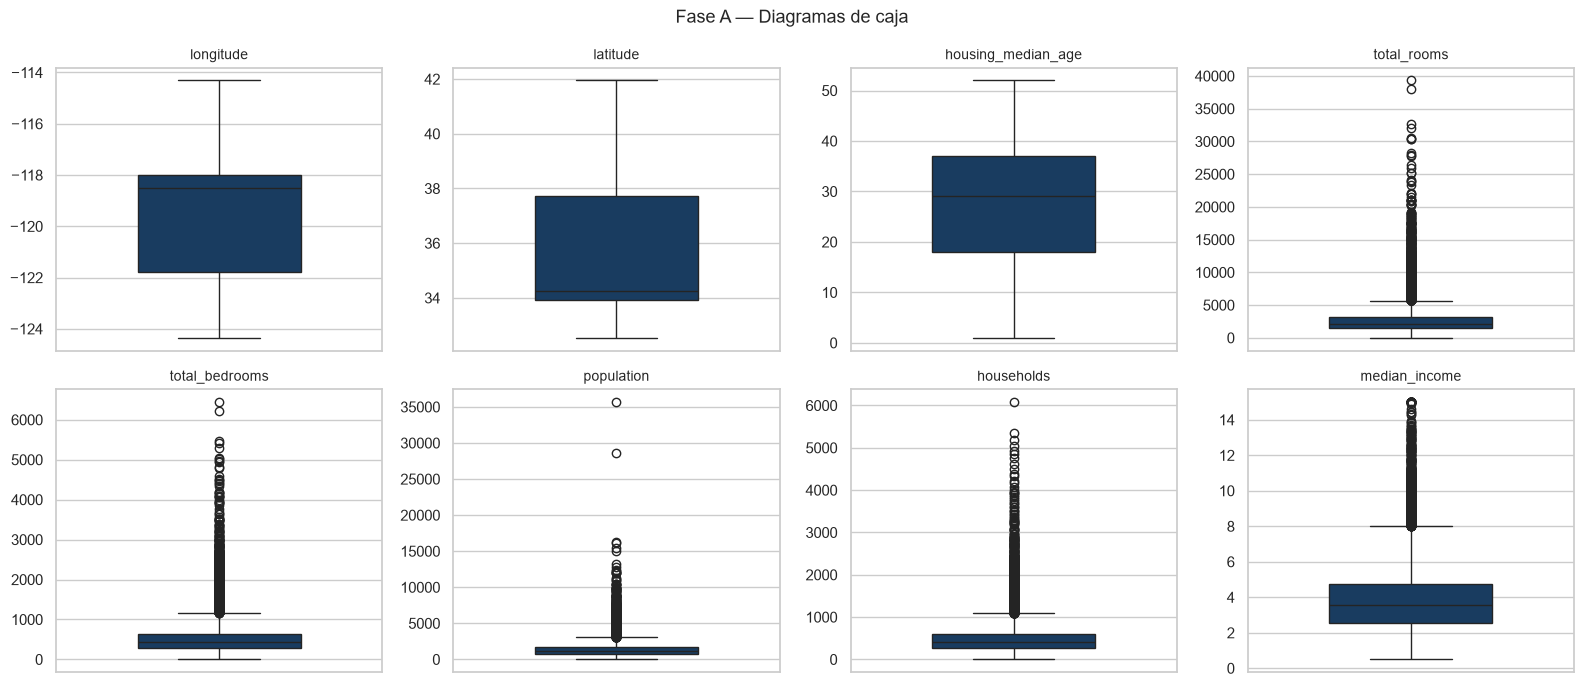

In [5]:
censurados = int((df[OBJETIVO] >= 500001).sum())
print(f"Registros en el tope de 500 001: {censurados} ({100*censurados/len(df):.2f} %)")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), NUMERICAS):
    sns.boxplot(y=df[c], ax=ax, color="#0d3c6c", width=.5)
    ax.set_title(c, fontsize=10); ax.set_ylabel("")
fig.suptitle("Fase A — Diagramas de caja", fontsize=13)
plt.tight_layout(); plt.show()

### Multicolinealidad: matriz de correlacion y VIF

El **Factor de Inflacion de la Varianza** mide cuanto se infla la varianza del
coeficiente de una variable por estar correlacionada con las demas:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

donde $R^2_j$ es el ajuste al regresar la variable $j$ contra todas las otras.
La lectura habitual es: **VIF > 5** moderada, **VIF > 10** severa.

La multicolinealidad **no impide predecir**, pero hace inestables e
ininterpretables los coeficientes individuales.

In [6]:
def calcular_vif(X):
    """VIF_j = 1 / (1 - R2_j), regresando cada variable contra las demas."""
    Z = StandardScaler().fit_transform(X)
    vif = {}
    for j, nombre in enumerate(X.columns):
        otras = [k for k in range(Z.shape[1]) if k != j]
        r2 = LinearRegression().fit(Z[:, otras], Z[:, j]).score(Z[:, otras], Z[:, j])
        vif[nombre] = 1 / (1 - r2)
    return pd.Series(vif).sort_values(ascending=False)


def diagnostico(v):
    return "SEVERA" if v > 10 else ("moderada" if v > 5 else "aceptable")

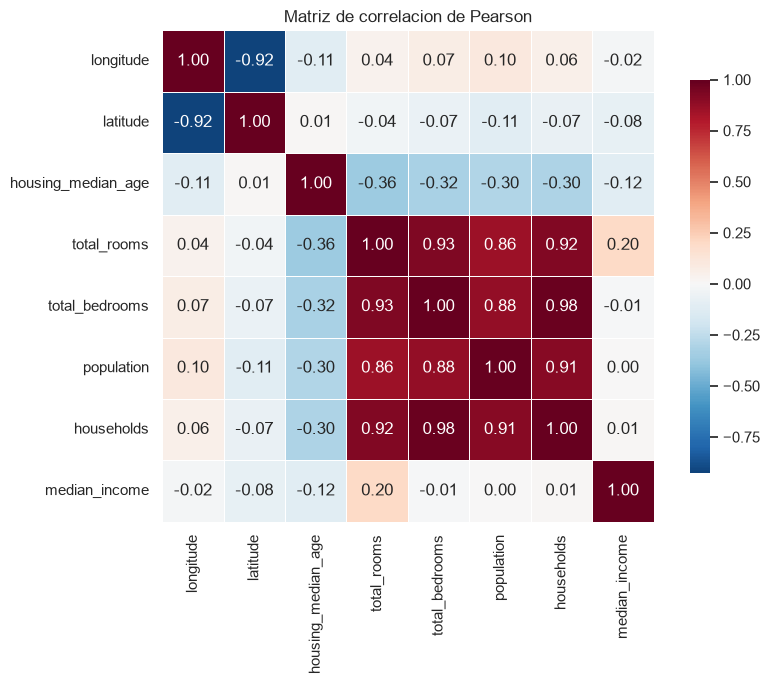

Pares con |r| > 0.5:
  longitude            - latitude             r = -0.9247
  total_rooms          - total_bedrooms       r = +0.9304
  total_rooms          - population           r = +0.8571
  total_rooms          - households           r = +0.9185
  total_bedrooms       - population           r = +0.8777
  total_bedrooms       - households           r = +0.9797
  population           - households           r = +0.9072


In [7]:
corr = df[NUMERICAS].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            linewidths=.5, ax=ax, cbar_kws={"shrink": .8})
ax.set_title("Matriz de correlacion de Pearson"); plt.tight_layout(); plt.show()

print("Pares con |r| > 0.5:")
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > .5:
            print(f"  {corr.index[i]:<20} - {corr.columns[j]:<20} r = {corr.iloc[i,j]:+.4f}")

,VIF,diagnostico
households,28.28,SEVERA
total_bedrooms,26.88,SEVERA
total_rooms,12.13,SEVERA
latitude,8.83,moderada
longitude,8.70,moderada
population,6.26,moderada
median_income,1.69,aceptable
housing_median_age,1.26,aceptable


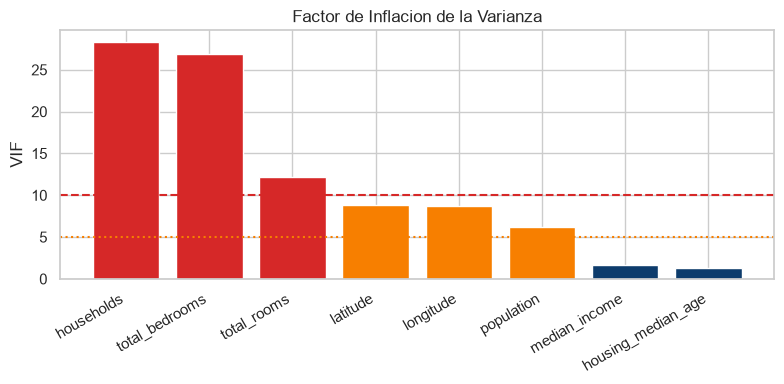

In [8]:
vif = calcular_vif(df[NUMERICAS].fillna(df[NUMERICAS].median()))
tabla_vif = pd.DataFrame({"VIF": vif.round(2), "diagnostico": vif.map(diagnostico)})
display(tabla_vif)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(vif.index, vif.values,
       color=["#d62828" if v > 10 else "#f77f00" if v > 5 else "#0d3c6c" for v in vif])
ax.axhline(10, ls="--", c="#d62828"); ax.axhline(5, ls=":", c="#f77f00")
ax.set_ylabel("VIF"); plt.xticks(rotation=30, ha="right")
ax.set_title("Factor de Inflacion de la Varianza"); plt.tight_layout(); plt.show()

`total_rooms`, `total_bedrooms`, `population` y `households` miden todas el **tamano del distrito**: de ahi su VIF elevado. Es multicolinealidad esperable y estructural. No impide predecir, pero desaconseja leer esos coeficientes por separado.

## Fase B — Modelamiento estadistico y comparativa

Se entrenan las **dos metodologias exigidas** compartiendo exactamente el mismo
preprocesamiento y la misma particion. La **unica** diferencia entre ellas es la
expansion polinomica, de modo que cualquier diferencia de rendimiento es
atribuible al modelo y no al tratamiento de los datos.

- **Regresion Lineal Multiple**: $\hat{y} = \beta_0 + \sum_i \beta_i z_i$
- **Regresion Polinomica grado 2**: anade terminos cuadraticos $z_i^2$ e
  interacciones $z_i z_j$. Sigue siendo **lineal en los parametros**, que es lo
  que define el metodo.

Se reportan tres medidas: R² de entrenamiento, R² de prueba y **R² de validacion
cruzada 5-fold**. La tercera es la mas fiable, porque promedia cinco particiones
distintas en lugar de depender de una sola.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

X, y = df[NUMERICAS + [CATEGORICA]], df[OBJETIVO]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=RANDOM_STATE)
print(f"Entrenamiento: {len(X_tr)}   Prueba: {len(X_te)}   (80 / 20)")

def pipeline_caso1(grado):
    pasos = [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    if grado > 1:
        pasos.append(("poly", PolynomialFeatures(degree=grado, include_bias=False)))
    return Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline(pasos), NUMERICAS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), [CATEGORICA])])),
        ("modelo", LinearRegression())])

def evaluar_caso1(nombre, grado):
    pipe = pipeline_caso1(grado).fit(X_tr, y_tr)
    p_tr, p_te = pipe.predict(X_tr), pipe.predict(X_te)
    cv = cross_val_score(pipe, X_tr, y_tr, cv=CV, scoring="r2")
    return {"modelo": nombre, "terminos": pipe.named_steps["modelo"].coef_.size,
            "R2_train": round(r2_score(y_tr, p_tr), 4),
            "R2_test": round(r2_score(y_te, p_te), 4),
            "R2_CV": round(cv.mean(), 4), "CV_std": round(cv.std(), 4),
            "brecha": round(r2_score(y_tr, p_tr) - cv.mean(), 4),
            "RMSE": round(np.sqrt(mean_squared_error(y_te, p_te)), 2),
            "MAE": round(mean_absolute_error(y_te, p_te), 2)}, pipe

Entrenamiento: 16512   Prueba: 4128   (80 / 20)


### Fase B.1 — Regresion Lineal Multiple

In [10]:
m_lin, pipe_lin = evaluar_caso1("Lineal multiple (OLS)", 1)
pd.Series(m_lin).to_frame("valor")

,valor
modelo,Lineal multiple (OLS)
terminos,13
R2_train,0.6497
R2_test,0.6254
R2_CV,0.6477
CV_std,0.0132
brecha,0.002
RMSE,70059.19
MAE,50670.49


### Fase B.2 — Regresion Polinomica grado 2

In [11]:
m_poly, pipe_poly = evaluar_caso1("Polinomica grado 2", 2)
pd.Series(m_poly).to_frame("valor")

,valor
modelo,Polinomica grado 2
terminos,49
R2_train,0.7053
R2_test,0.657
R2_CV,0.6262
CV_std,0.1333
brecha,0.0791
RMSE,67043.55
MAE,46981.22


### Fase B.3 — Comparativa

In [12]:
comp = pd.DataFrame([m_lin, m_poly]).set_index("modelo")
display(comp)
print(f"Ganancia en R2 de prueba : {m_poly['R2_test'] - m_lin['R2_test']:+.4f}")
print(f"Diferencia en MAE        : {m_poly['MAE'] - m_lin['MAE']:+,.2f} US$")
print(f"R2 de validacion cruzada : lineal {m_lin['R2_CV']:.4f} +- {m_lin['CV_std']:.3f}"
      f"  |  polinomica {m_poly['R2_CV']:.4f} +- {m_poly['CV_std']:.3f}")

,terminos,R2_train,R2_test,R2_CV,CV_std,brecha,RMSE,MAE
modelo,,,,,,,,
Lineal multiple (OLS),13,0.6497,0.6254,0.6477,0.0132,0.0020,70059.19,50670.49
Polinomica grado 2,49,0.7053,0.6570,0.6262,0.1333,0.0791,67043.55,46981.22


Ganancia en R2 de prueba : +0.0316
Diferencia en MAE        : -3,689.27 US$
R2 de validacion cruzada : lineal 0.6477 +- 0.013  |  polinomica 0.6262 +- 0.133


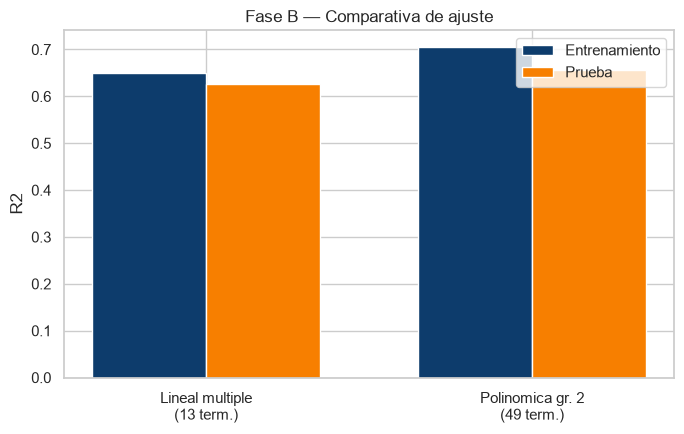

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
et = [f"Lineal multiple\n({m_lin['terminos']} term.)", f"Polinomica gr. 2\n({m_poly['terminos']} term.)"]
x, an = np.arange(2), .35
ax.bar(x - an/2, [m_lin["R2_train"], m_poly["R2_train"]], an, label="Entrenamiento", color="#0d3c6c")
ax.bar(x + an/2, [m_lin["R2_test"], m_poly["R2_test"]], an, label="Prueba", color="#f77f00")
ax.set_xticks(x); ax.set_xticklabels(et); ax.set_ylabel("R2"); ax.legend()
ax.set_title("Fase B — Comparativa de ajuste"); plt.tight_layout(); plt.show()

### Conclusion del Caso 1

La expansion polinomica **mejora el R² de prueba** (+0.0316) y **reduce el MAE** en unos
US$ 3 689: con 20 640 registros hay muestra suficiente para estimar 49 coeficientes, y las
interacciones entre coordenadas geograficas e ingreso capturan estructura espacial real.

Sin embargo, la lectura no es unanime. En **validacion cruzada** el orden se invierte y,
sobre todo, la **desviacion entre particiones** del polinomio es un orden de magnitud mayor:
es un modelo mas potente pero **mucho menos estable**. La brecha entrenamiento−CV tambien
crece de forma notable.

**Conclusion honesta:** el polinomio es preferible en este dominio por su mejor error de
prueba, pero conviene reportar su inestabilidad en lugar de presentarlo como una victoria
limpia.